In [28]:
## Add kaggle.json file in upload

# from google.colab import files
# files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install -q kaggle
!kaggle datasets download -d gopalbhattrai/pascal-voc-2012-dataset
!unzip -q pascal-voc-2012-dataset.zip -d voc2012

Dataset URL: https://www.kaggle.com/datasets/gopalbhattrai/pascal-voc-2012-dataset
License(s): unknown
 99% 3.50G/3.52G [00:39<00:00, 29.4MB/s]
100% 3.52G/3.52G [00:40<00:00, 94.5MB/s]


In [ ]:
!mkdir -p coco2017

!echo "📥 Downloading val2017 images..."
!wget --no-check-certificate https://images.cocodataset.org/zips/val2017.zip -O coco2017/val2017.zip

!echo "📥 Downloading annotations..."
!wget --no-check-certificate https://images.cocodataset.org/annotations/annotations_trainval2017.zip -O coco2017/annotations_trainval2017.zip

!echo "📦 Unzipping val2017..."
!unzip -q coco2017/val2017.zip -d coco2017/

!echo "📦 Unzipping annotations..."
!unzip -q coco2017/annotations_trainval2017.zip -d coco2017/

!ls coco2017

📥 Downloading val2017 images...
--2025-06-08 05:10:17--  https://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.70.228, 3.5.30.193, 52.217.120.105, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.70.228|:443... connected.
	requested host name ‘images.cocodataset.org’.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘coco2017/val2017.zip’

coco2017/val2017.zi 100%[===================>] 777.80M  95.8MB/s    in 8.2s    

2025-06-08 05:10:26 (95.3 MB/s) - ‘coco2017/val2017.zip’ saved [815585330/815585330]

📥 Downloading annotations...
--2025-06-08 05:10:26--  https://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.25.93, 3.5.29.194, 52.216.37.1, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.25.93|:443... connected.
	requested host name ‘images.cocoda

In [ ]:
!pip install xmltodict

In [ ]:
import os, cv2, xmltodict
import matplotlib.pyplot as plt

In [ ]:
def show_voc(image_id, base='/content/voc2012/VOC2012_train_val/VOC2012_train_val'):
    import os, cv2, xmltodict
    import matplotlib.pyplot as plt

    img_path = os.path.join(base, 'JPEGImages', f'{image_id}.jpg')
    xml_path = os.path.join(base, 'Annotations', f'{image_id}.xml')

    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        return

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    with open(xml_path) as f:
        data = xmltodict.parse(f.read())['annotation']

    objs = data['object']
    if not isinstance(objs, list): objs = [objs]

    for obj in objs:
        name = obj['name']
        b = obj['bndbox']
        x1, y1, x2, y2 = map(int, [b['xmin'], b['ymin'], b['xmax'], b['ymax']])
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.imshow(img)
    plt.axis('off')
    plt.title(image_id)
    plt.show()

In [ ]:
import os

# List some valid image IDs
image_dir = '/content/voc2012/VOC2012_train_val/VOC2012_train_val/JPEGImages'
image_files = os.listdir(image_dir)
image_ids = [f.split('.')[0] for f in image_files if f.endswith('.jpg')]

# Show first 5
print("Sample image IDs:", image_ids[:5])


Sample image IDs: ['2008_002322', '2011_000596', '2011_001341', '2010_002309', '2007_005688']


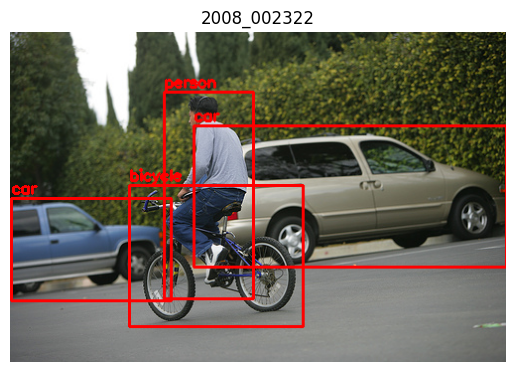

In [ ]:
show_voc("2008_002322")

In [ ]:
from pycocotools.coco import COCO

In [ ]:
def show_coco(data_dir='coco2017'):
    coco = COCO(f"{data_dir}/annotations/instances_val2017.json")
    img_id = coco.getImgIds()[0]
    img_info = coco.loadImgs(img_id)[0]
    path = os.path.join(data_dir, "val2017", img_info['file_name'])
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    for ann in anns:
        x,y,w,h = map(int, ann['bbox'])
        cat = coco.loadCats(ann['category_id'])[0]['name']
        cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(img, cat, (x,y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    plt.imshow(img); plt.axis('off'); plt.title(img_info['file_name'])
    plt.show()

loading annotations into memory...
Done (t=0.84s)
creating index...
index created!


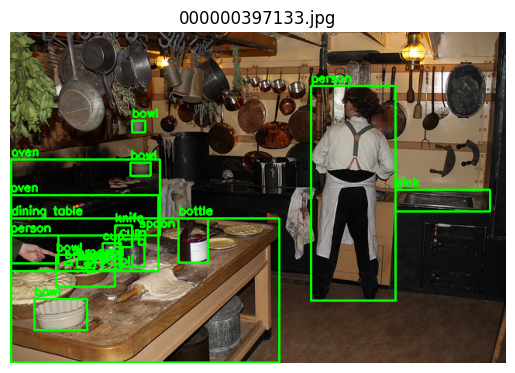

In [27]:
show_coco(data_dir='coco2017')